## Cell 1: 导入库和基础配置

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# 设置中文字体和可视化样式
plt.rcParams['font.sans-serif'] = ['Arial Unicode MS', 'SimHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False
sns.set_style("whitegrid")
sns.set_palette("husl")

print("Successfully Imported")
print(f"分析时间: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")

Successfully Imported
分析时间: 2025-11-25 10:33:58


## Cell 2: 配置参数（可根据业务调整）

In [22]:
# ==================== 业务配置参数 ====================

CONFIG = {
    # 数据量阈值
    'min_spend_for_decision': 100,  # 花费低于100美金视为数据不足
    'min_purchases_significant': 10,  # 至少10个转化才有统计意义
    
    # ROAS阈值
    'roas_excellent': 5.0,      # ROAS>=5 优秀
    'roas_good': 3.5,          # ROAS>=3.5 良好
    'roas_acceptable': 2.5,    # ROAS>=2.5 可接受
    'roas_breakeven': 1.5,     # ROAS>=1.5 保本
    # ROAS<1.5 亏损
    
    # CPM阈值（欧洲市场参考）
    'cpm_excellent': 3.0,      # CPM<=3 优秀
    'cpm_good': 5.0,          # CPM<=5 良好
    'cpm_acceptable': 8.0,    # CPM<=8 可接受
    # CPM>8 偏高
    
    # 频次阈值
    'frequency_warning': 2.5,  # 频次>2.5需要关注广告疲劳
    
    # 评分权重（总和=100）
    'weight_roas': 50,         # ROAS权重50%
    'weight_scale': 20,        # 花费规模权重20%（数据可靠性）
    'weight_conversion': 15,   # 转化数量权重15%
    'weight_cpm': 15,          # CPM权重15%
}

# 决策阈值
DECISION_THRESHOLDS = {
    'scale_up': 0.75,          # 得分>=0.75 强烈建议加预算
    'continue_optimize': 0.60, # 得分>=0.60 建议继续投放并优化
    'observe': 0.45,           # 得分>=0.45 可继续小额测试/观察
    # 得分<0.45 考虑暂停
}

print("配置参数设置完成")
print(f"ROAS阈值: 优秀>={CONFIG['roas_excellent']}, 良好>={CONFIG['roas_good']}, 可接受>={CONFIG['roas_acceptable']}")
print(f"最小决策花费: ${CONFIG['min_spend_for_decision']}")

配置参数设置完成
ROAS阈值: 优秀>=5.0, 良好>=3.5, 可接受>=2.5
最小决策花费: $100


## Cell 3: 读取和清洗数据

In [24]:
# Read Meta Data File
ads_path = 'Firmoo-ES-Ads-Oct-26-2025-Nov-24-2025.csv'
ads = pd.read_csv(ads_path, encoding='utf-8')

print(f"原始数据: {ads.shape[0]} 行, {ads.shape[1]} 列")

# Data Cleaning
# Normalize Columns
ads['spend_usd'] = ads['Amount spent (USD)']
ads['purchases'] = ads['Purchases']
ads['roas'] = ads['Purchase ROAS (return on ad spend)']
ads['cpa'] = ads['Cost per results']
ads['cpm'] = ads['CPM (cost per 1,000 impressions) (USD)']
ads['reach'] = ads['Reach']
ads['impressions'] = ads['Impressions']
ads['frequency'] = ads['Frequency']
ads['budget_usd'] = ads['Ad set budget']
ads['budget_type'] = ads['Ad set budget type']

# Keep the Active Ads
active_ads = ads[ads['Ad delivery'] == 'active'].copy()

print(f"活跃广告: {active_ads.shape[0]} 条")

# 数据质量统计
print("\n数据质量概览:")
print("=========================")
print(f"有花费的广告: {(active_ads['spend_usd'] > 0).sum()} 条")
print(f"有转化的广告: {(active_ads['purchases'] > 0).sum()} 条")
print(f"无转化的广告: {active_ads['purchases'].isna().sum() + (active_ads['purchases'] == 0).sum()} 条")
print(f"花费>${CONFIG['min_spend_for_decision']}的广告: {(active_ads['spend_usd'] >= CONFIG['min_spend_for_decision']).sum()} 条")

# 处理无转化情况：purchases为空或0都视为0
active_ads['purchases'] = active_ads['purchases'].fillna(0)

# ROAS为空时，如果有转化就设为一个小值，如果无转化就是0
active_ads.loc[active_ads['roas'].isna() & (active_ads['purchases'] > 0), 'roas'] = 0.5
active_ads.loc[active_ads['roas'].isna() & (active_ads['purchases'] == 0), 'roas'] = 0

print("\n数据清洗完成!")

原始数据: 357 行, 25 列
活跃广告: 194 条

数据质量概览:
有花费的广告: 194 条
有转化的广告: 129 条
无转化的广告: 65 条
花费>$100的广告: 98 条

数据清洗完成!


## Cell 4: 评分函数

In [25]:
def calculate_ad_score(row):
    """
    计算广告综合得分
    
    评分逻辑:
    1. ROAS得分 (50分): 核心指标
    2. 花费得分 (20分): 花费规模反映数据可靠性
    3. 转化得分 (15分): 绝对转化数量
    4. CPM得分 (15分): 流量成本效率
    
    返回: 0-1之间的标准化分数
    """
    
    spend = row['spend_usd']
    purchases = row['purchases']
    roas = row['roas']
    cpm = row['cpm']
    
    # 1. ROAS得分 (0-50分)
    if roas >= CONFIG['roas_excellent']:
        roas_score = 50
    elif roas >= CONFIG['roas_good']:
        # 3.5-5.0之间线性插值
        roas_score = 40 + (roas - CONFIG['roas_good']) / (CONFIG['roas_excellent'] - CONFIG['roas_good']) * 10
    elif roas >= CONFIG['roas_acceptable']:
        # 2.5-3.5之间
        roas_score = 30 + (roas - CONFIG['roas_acceptable']) / (CONFIG['roas_good'] - CONFIG['roas_acceptable']) * 10
    elif roas >= CONFIG['roas_breakeven']:
        # 1.5-2.5之间
        roas_score = 15 + (roas - CONFIG['roas_breakeven']) / (CONFIG['roas_acceptable'] - CONFIG['roas_breakeven']) * 15
    elif roas > 0:
        # 0-1.5之间
        roas_score = (roas / CONFIG['roas_breakeven']) * 15
    else:
        roas_score = 0
    
    # 2. 规模得分 (0-20分)
    # 花费越多，数据越可靠
    if spend >= 500:
        scale_score = 20
    elif spend >= 300:
        scale_score = 17
    elif spend >= 150:
        scale_score = 13
    elif spend >= 100:
        scale_score = 10
    elif spend >= 50:
        scale_score = 6
    else:
        scale_score = 3
    
    # 3. 转化得分 (0-15分)
    if purchases >= 50:
        conversion_score = 15
    elif purchases >= 30:
        conversion_score = 13
    elif purchases >= 20:
        conversion_score = 11
    elif purchases >= 10:
        conversion_score = 9
    elif purchases >= 5:
        conversion_score = 6
    elif purchases > 0:
        conversion_score = 3
    else:
        conversion_score = 0  # 无转化得0分
    
    # 4. CPM得分 (0-15分)
    # CPM越低越好
    if pd.isna(cpm):
        cpm_score = 8  # 中性分数
    elif cpm <= CONFIG['cpm_excellent']:
        cpm_score = 15
    elif cpm <= CONFIG['cpm_good']:
        cpm_score = 12 - (cpm - CONFIG['cpm_excellent']) / (CONFIG['cpm_good'] - CONFIG['cpm_excellent']) * 3
    elif cpm <= CONFIG['cpm_acceptable']:
        cpm_score = 8 - (cpm - CONFIG['cpm_good']) / (CONFIG['cpm_acceptable'] - CONFIG['cpm_good']) * 4
    else:
        # CPM>8，分数快速下降 - 每增加1美金扣0.8分
        cpm_score = max(0, 8 - (cpm - CONFIG['cpm_acceptable']) * 0.8)
    
    # 综合得分
    total_score = roas_score + scale_score + conversion_score + cpm_score
    normalized_score = total_score / 100  # 标准化到0-1
    
    return normalized_score


def make_decision(row):
    """
    根据得分和业务规则做出决策
    """
    
    score = row['ad_score']
    spend = row['spend_usd']
    roas = row['roas']
    purchases = row['purchases']
    
    # 数据不足的情况
    if spend < CONFIG['min_spend_for_decision']:
        return '数据不足,继续测试'
    
    # 高分且高ROAS
    if score >= DECISION_THRESHOLDS['scale_up'] and roas >= CONFIG['roas_good']:
        return '强烈建议加预算'
    
    # 中高分且ROAS可接受
    if score >= DECISION_THRESHOLDS['continue_optimize'] and roas >= CONFIG['roas_acceptable']:
        return '建议继续投放并优化'
    
    # 中等分数或ROAS刚过保本线
    if score >= DECISION_THRESHOLDS['observe'] or (roas >= CONFIG['roas_breakeven'] and spend >= 100):
        return '可继续小额测试/观察'
    
    # 其他情况：低分或亏损
    return '建议暂停或重做'


print("评分函数定义完成")
print("\n评分逻辑:")
print(f"  ROAS得分: {CONFIG['weight_roas']}分")
print(f"  规模得分: {CONFIG['weight_scale']}分")
print(f"  转化得分: {CONFIG['weight_conversion']}分")
print(f"  CPM得分: {CONFIG['weight_cpm']}分")

评分函数定义完成

评分逻辑:
  ROAS得分: 50分
  规模得分: 20分
  转化得分: 15分
  CPM得分: 15分


## Cell 5: 执行评分和决策

In [26]:
# 计算得分
print("开始计算广告得分...")

active_ads['ad_score'] = active_ads.apply(calculate_ad_score, axis=1)
active_ads['decision'] = active_ads.apply(make_decision, axis=1)

# 添加辅助字段
# 标注是否有转化
active_ads['has_conversion'] = active_ads['purchases'] > 0

# 标注频次预警
active_ads['frequency_warning'] = active_ads['frequency'] > CONFIG['frequency_warning']

# 决策优先级排序
decision_priority_map = {
    '强烈建议加预算': 1,
    '建议继续投放并优化': 2,
    '可继续小额测试/观察': 3,
    '数据不足,继续测试': 4,
    '建议暂停或重做': 5,
}
active_ads['decision_priority'] = active_ads['decision'].map(decision_priority_map)

# 排序
scored_ads = active_ads.sort_values(
    ['decision_priority', 'ad_score'], 
    ascending=[True, False]
).reset_index(drop=True)

print("评分完成！")
print(f"\n决策分布:")
for decision, count in scored_ads['decision'].value_counts().items():
    pct = count / len(scored_ads) * 100
    total_spend = scored_ads[scored_ads['decision'] == decision]['spend_usd'].sum()
    print(f"  {decision:25s}: {count:3d}条 ({pct:5.1f}%) | 花费: ${total_spend:,.2f}")

开始计算广告得分...
评分完成！

决策分布:
  数据不足,继续测试                :  96条 ( 49.5%) | 花费: $1,848.22
  强烈建议加预算                  :  35条 ( 18.0%) | 花费: $32,881.62
  可继续小额测试/观察               :  27条 ( 13.9%) | 花费: $26,619.45
  建议继续投放并优化                :  23条 ( 11.9%) | 花费: $15,416.55
  建议暂停或重做                  :  13条 (  6.7%) | 花费: $2,265.74


## Cell 6: 数据总结和关键指标

In [27]:
# ==================== 整体表现统计 ====================
print("=" * 80)
print("整体表现分析")
print("=" * 80)

total_spend = scored_ads['spend_usd'].sum()
total_purchases = scored_ads['purchases'].sum()
ads_with_conversion = (scored_ads['purchases'] > 0).sum()

# 加权平均ROAS（按花费加权）
weighted_roas = (scored_ads['roas'] * scored_ads['spend_usd']).sum() / total_spend

print(f"\n总体指标:")
print(f"  活跃广告数: {len(scored_ads)} 条")
print(f"  总花费: ${total_spend:,.2f}")
print(f"  总转化: {total_purchases:.0f} 次")
print(f"  有转化的广告: {ads_with_conversion} 条 ({ads_with_conversion/len(scored_ads)*100:.1f}%)")
print(f"  加权平均ROAS: {weighted_roas:.2f}")

# ==================== 分类详细统计 ====================
print(f"\n分类详细统计:")

for decision in ['强烈建议加预算', '建议继续投放并优化', '可继续小额测试/观察', '数据不足,继续测试', '建议暂停或重做']:
    subset = scored_ads[scored_ads['decision'] == decision]
    if len(subset) == 0:
        continue
    
    count = len(subset)
    spend = subset['spend_usd'].sum()
    purchases = subset['purchases'].sum()
    
    # 计算该类别的平均ROAS（只计算有花费的）
    if spend > 0:
        avg_roas = (subset['roas'] * subset['spend_usd']).sum() / spend
        avg_cpa = spend / purchases if purchases > 0 else 0
    else:
        avg_roas = 0
        avg_cpa = 0
    
    print(f"\n  [{decision}]")
    print(f"    数量: {count} 条 ({count/len(scored_ads)*100:.1f}%)")
    print(f"    花费: ${spend:,.2f} ({spend/total_spend*100:.1f}%)")
    print(f"    转化: {purchases:.0f} 次")
    if spend > 0 and purchases > 0:
        print(f"    平均ROAS: {avg_roas:.2f}")
        print(f"    平均CPA: ${avg_cpa:.2f}")
    
    # 显示具体广告列表
    print(f"\n    具体广告列表:")
    for idx, row in subset.iterrows():
        ad_name = row['Ad name']
        ad_set = row['Ad set name']
        ad_spend = row['spend_usd']
        ad_purchases = row['purchases']
        ad_roas = row['roas']
        ad_score = row['ad_score']
        budget_usd = row['budget_usd']
        budget_type = row['budget_type']
        
        print(f"      - {ad_name} ({ad_set})")
        print(f"        花费: ${ad_spend:.2f} | 转化: {ad_purchases:.0f} | ROAS: {ad_roas:.2f} | 得分: {ad_score:.3f}")
        if pd.notna(budget_usd) and budget_usd != 0:
            print(f"        预算: ${budget_usd} ({budget_type})")
        else:
            print(f"        预算: 未设置 ({budget_type})")

print("\n" + "=" * 80)

整体表现分析

总体指标:
  活跃广告数: 194 条
  总花费: $79,031.58
  总转化: 4278 次
  有转化的广告: 129 条 (66.5%)
  加权平均ROAS: 3.20

分类详细统计:

  [强烈建议加预算]
    数量: 35 条 (18.0%)
    花费: $32,881.62 (41.6%)
    转化: 2520 次
    平均ROAS: 4.78
    平均CPA: $13.05

    具体广告列表:
      - 爆款系列 (ES-转化-商品系列-爆款)
        花费: $2831.71 | 转化: 243 | ROAS: 5.10 | 得分: 1.000
        预算: $300 (Daily)
      - DAPA-595-AP (DAPA-595)
        花费: $1952.99 | 转化: 165 | ROAS: 4.99 | 得分: 1.000
        预算: $140 (Daily)
      - 爆款系列-图9 (ES-转化-商品系列-爆款)
        花费: $506.06 | 转化: 44 | ROAS: 6.59 | 得分: 0.980
        预算: $300 (Daily)
      - Clips (ES-转化-商品系列-套镜-Catalog Ad set)
        花费: $1512.25 | 转化: 121 | ROAS: 5.02 | 得分: 0.969
        预算: $50 (Daily)
      - ASC4 (博主-ASC4)
        花费: $1273.69 | 转化: 124 | ROAS: 5.83 | 得分: 0.964
        预算: $120 (Daily)
      - SG (太阳镜- Catalog)
        花费: $1509.28 | 转化: 135 | ROAS: 5.84 | 得分: 0.961
        预算: $50 (Daily)
      - TJ (商品系列-套镜)
        花费: $950.65 | 转化: 77 | ROAS: 6.37 | 得分: 0.951
        预算: $70 (Daily

## Cell 7: 创建展示表格并保存

In [33]:
# ==================== 创建展示DataFrame ====================
display_cols = [
    'Ad name',
    'Ad set name', 
    'spend_usd',
    'purchases',
    'roas',
    'cpa',
    'cpm',
    'frequency',
    'budget_usd',
    'budget_type',
    'ad_score',
    'decision'
]

result_display = scored_ads[display_cols].copy()
result_display['ad_score'] = result_display['ad_score'].round(3)
result_display['roas'] = result_display['roas'].round(2)
result_display['cpa'] = result_display['cpa'].round(2)
result_display['cpm'] = result_display['cpm'].round(2)
result_display['frequency'] = result_display['frequency'].round(2)
result_display['spend_usd'] = result_display['spend_usd'].round(2)

# 显示前30条广告（业务优先级排序后）
print("显示前30条广告(业务优先级排序后):")
result_display.head(30)

显示前30条广告(业务优先级排序后):


,Ad name,Ad set name,spend_usd,purchases,roas,cpa,cpm,frequency,budget_usd,budget_type,ad_score,decision
0,爆款系列,ES-转化-商品系列-爆款,2831.71,243.0,5.10,11.65,2.44,2.83,300,Daily,1.000,强烈建议加预算
1,DAPA-595-AP,DAPA-595,1952.99,165.0,4.99,11.84,2.95,3.88,140,Daily,1.000,强烈建议加预算
2,爆款系列-图9,ES-转化-商品系列-爆款,506.06,44.0,6.59,11.50,2.53,2.22,300,Daily,0.980,强烈建议加预算
3,Clips,ES-转化-商品系列-套镜-Catalog Ad set,1512.25,121.0,5.02,12.50,3.09,3.46,50,Daily,0.969,强烈建议加预算
4,ASC4,博主-ASC4,1273.69,124.0,5.83,10.27,3.41,1.63,120,Daily,0.964,强烈建议加预算
5,SG,太阳镜- Catalog,1509.28,135.0,5.84,11.18,3.60,3.74,50,Daily,0.961,强烈建议加预算
6,TJ,商品系列-套镜,950.65,77.0,6.37,12.35,4.26,1.74,70,Daily,0.951,强烈建议加预算
7,TJC,商品系列-TJC,1784.03,139.0,4.65,12.83,3.86,2.53,120,Daily,0.934,强烈建议加预算
8,TJ-DB,用户诉求-套镜-对比,1133.99,85.0,4.63,13.34,4.03,1.83,70,Daily,0.930,强烈建议加预算
9,ASC4,博主-ASC4,618.12,53.0,5.31,11.66,5.31,1.63,120,Daily,0.926,强烈建议加预算


In [30]:
# 显示末尾30条广告（表现最差的）
print("显示末尾30条广告(表现最差):")
result_display.tail(30)

显示末尾30条广告(表现最差):


,Ad name,Ad set name,spend_usd,purchases,roas,cpa,cpm,frequency,budget_usd,budget_type,ad_score,decision
164,BF2,TOP-BF2,1.43,0.0,0.00,NaN,6.36,1.06,100,Daily,0.092,"数据不足,继续测试"
165,POPM1,战略部-MGAPOP MIX,20.44,0.0,0.00,10.22,6.40,1.27,Using campaign budget,0,0.091,"数据不足,继续测试"
166,POP07 4,战略部-MGAPOP MIX,3.39,0.0,0.00,3.39,6.42,1.14,Using campaign budget,0,0.091,"数据不足,继续测试"
167,POP03,战略部-MGAPOP MIX,3.91,0.0,0.00,1.30,6.45,1.18,Using campaign budget,0,0.091,"数据不足,继续测试"
168,BF2,TOP-BF2,2.37,0.0,0.00,NaN,6.60,1.10,100,Daily,0.089,"数据不足,继续测试"
169,BF2-1€,TOF-BF2-1€,10.22,0.0,0.00,NaN,6.60,1.15,70,Daily,0.089,"数据不足,继续测试"
170,1121 POP02,战略部-MGAPOP MIX,1.05,0.0,0.00,NaN,11.05,1.10,Using campaign budget,0,0.086,"数据不足,继续测试"
171,1121 POPV,战略部-MGAPOP MIX,0.29,0.0,0.00,NaN,6.90,1.05,Using campaign budget,0,0.085,"数据不足,继续测试"
172,混搭1,组2-混合,10.99,0.0,0.00,1.00,6.96,1.55,70,Daily,0.084,"数据不足,继续测试"
173,BF2-1€,TOF-BF2-1€,2.78,0.0,0.00,2.78,7.07,1.26,70,Daily,0.082,"数据不足,继续测试"


## Cell 8: 可视化分析

使用字体: Arial Unicode MS
生成可视化图表...


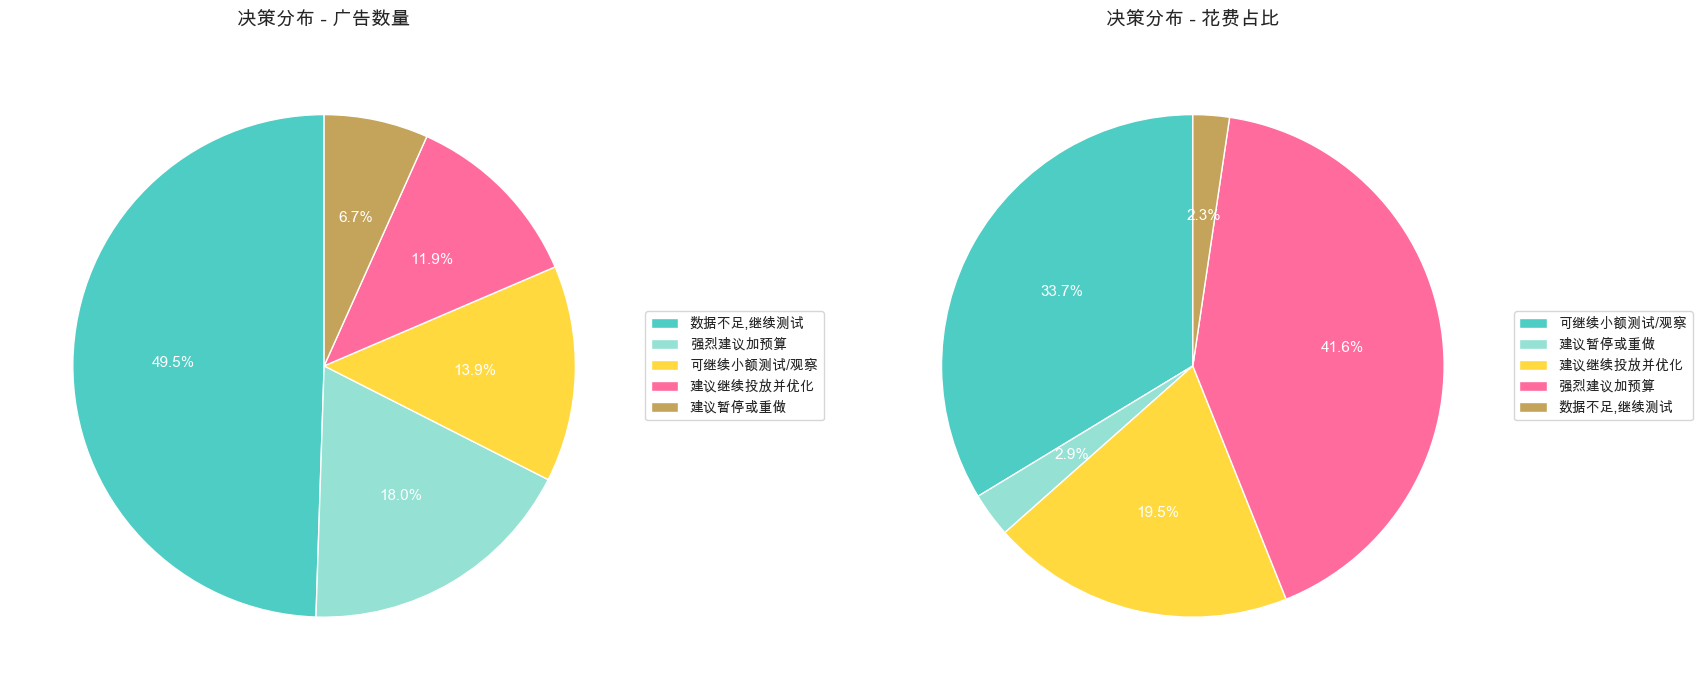

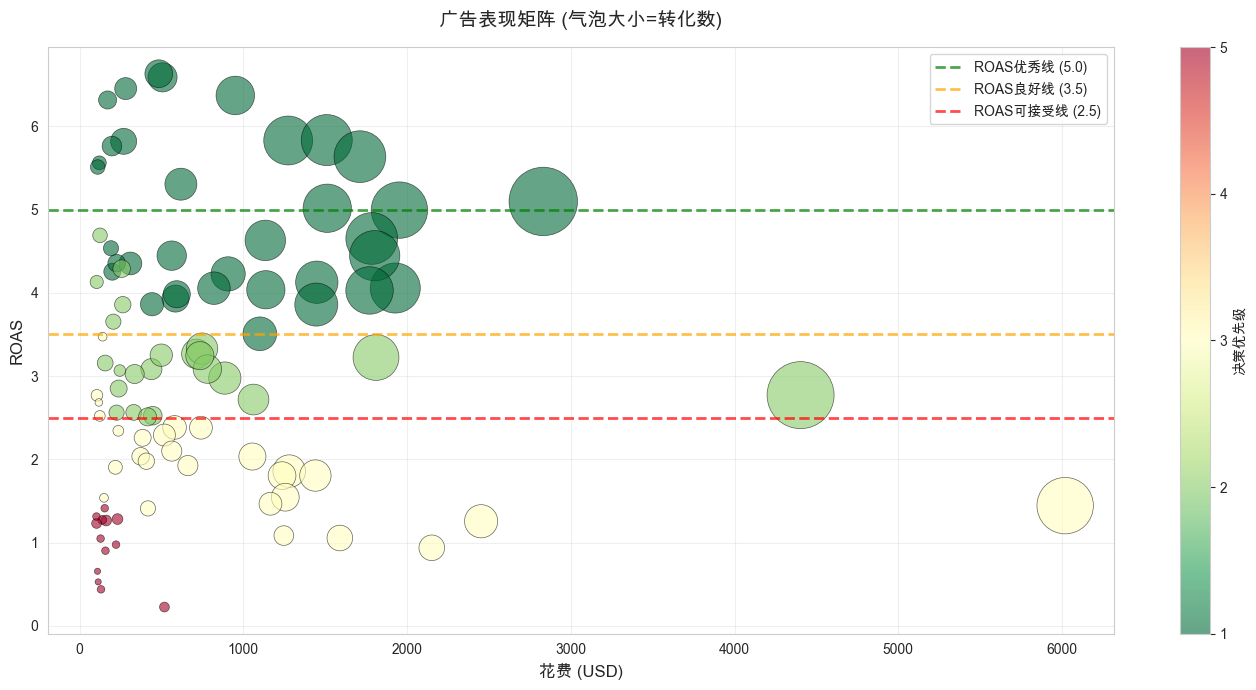


决策汇总统计表
            广告数    总花费($)     总转化  平均ROAS  平均CPM  花费占比(%)  平均CPA($)
decision                                                           
强烈建议加预算      35  32881.62  2520.0    4.92   4.38     41.6     13.05
建议继续投放并优化    23  15416.55   849.0    3.21   4.60     19.5     18.16
可继续小额测试/观察   27  26619.45   781.0    1.94   4.15     33.7     34.08
数据不足,继续测试    96   1848.22    80.0    1.72   5.48      2.3     23.10
建议暂停或重做      13   2265.74    48.0    0.97   4.60      2.9     47.20


In [31]:
import matplotlib.font_manager as fm
import platform

system = platform.system()
if system == 'Darwin':  # macOS
    fonts_to_try = ['Arial Unicode MS', 'PingFang SC', 'Heiti SC', 'STHeiti']
elif system == 'Windows':
    fonts_to_try = ['Microsoft YaHei', 'SimHei', 'SimSun']
else:  # Linux
    fonts_to_try = ['WenQuanYi Micro Hei', 'Droid Sans Fallback']

available_fonts = set([f.name for f in fm.fontManager.ttflist])
for font in fonts_to_try:
    if font in available_fonts:
        plt.rcParams['font.sans-serif'] = [font]
        print(f"使用字体: {font}")
        break

plt.rcParams['axes.unicode_minus'] = False

# 开始生成图表
print("="*80)
print("生成可视化图表...")
print("="*80)

# 1. 决策分布双饼图
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

decision_counts = scored_ads['decision'].value_counts()
colors = ['#4ECDC4', '#95E1D3', '#FFD93D', '#FF6B9D', '#C4A35A']

# 左图: 广告数量
wedges1, _, autotexts1 = axes[0].pie(
    decision_counts.values, 
    autopct='%1.1f%%',
    colors=colors,
    startangle=90,
    textprops={'fontsize': 11, 'weight': 'bold', 'color': 'white'}
)
axes[0].set_title('决策分布 - 广告数量', fontsize=14, weight='bold', pad=20)
axes[0].legend(wedges1, decision_counts.index, loc="center left", 
               bbox_to_anchor=(1, 0, 0.5, 1), fontsize=10)

# 右图: 花费分布
decision_spend = scored_ads.groupby('decision')['spend_usd'].sum()
wedges2, _, autotexts2 = axes[1].pie(
    decision_spend.values,
    autopct='%1.1f%%',
    colors=colors,
    startangle=90,
    textprops={'fontsize': 11, 'weight': 'bold', 'color': 'white'}
)
axes[1].set_title('决策分布 - 花费占比', fontsize=14, weight='bold', pad=20)
axes[1].legend(wedges2, decision_spend.index, loc="center left",
               bbox_to_anchor=(1, 0, 0.5, 1), fontsize=10)

plt.tight_layout()
plt.show()

# 2. ROAS vs 花费散点图
plt.figure(figsize=(14, 7))
plot_data = scored_ads[scored_ads['spend_usd'] >= CONFIG['min_spend_for_decision']].copy()

scatter = plt.scatter(plot_data['spend_usd'], 
                      plot_data['roas'],
                      s=plot_data['purchases']*10,
                      c=plot_data['decision_priority'],
                      cmap='RdYlGn_r',
                      alpha=0.6,
                      edgecolors='black',
                      linewidth=0.5)

plt.axhline(y=CONFIG['roas_excellent'], color='green', linestyle='--', 
            linewidth=2, label=f"ROAS优秀线 ({CONFIG['roas_excellent']})", alpha=0.7)
plt.axhline(y=CONFIG['roas_good'], color='orange', linestyle='--', 
            linewidth=2, label=f"ROAS良好线 ({CONFIG['roas_good']})", alpha=0.7)
plt.axhline(y=CONFIG['roas_acceptable'], color='red', linestyle='--', 
            linewidth=2, label=f"ROAS可接受线 ({CONFIG['roas_acceptable']})", alpha=0.7)

plt.xlabel('花费 (USD)', fontsize=12, weight='bold')
plt.ylabel('ROAS', fontsize=12, weight='bold')
plt.title('广告表现矩阵 (气泡大小=转化数)', fontsize=14, weight='bold', pad=15)
plt.legend(loc='upper right', fontsize=10)
plt.grid(True, alpha=0.3)
plt.colorbar(scatter, label='决策优先级', ticks=[1,2,3,4,5])
plt.tight_layout()
plt.show()

# 3. 数据汇总表
print("\n" + "="*80)
print("决策汇总统计表")
print("="*80)

summary = scored_ads.groupby('decision').agg({
    'Ad name': 'count',
    'spend_usd': 'sum',
    'purchases': 'sum',
    'roas': 'mean',
    'cpm': 'mean'
}).round(2)

summary.columns = ['广告数', '总花费($)', '总转化', '平均ROAS', '平均CPM']
summary['花费占比(%)'] = (summary['总花费($)'] / summary['总花费($)'].sum() * 100).round(1)
summary['平均CPA($)'] = (summary['总花费($)'] / summary['总转化']).round(2)

priority_order = ['强烈建议加预算', '建议继续投放并优化', '可继续小额测试/观察', '数据不足,继续测试', '建议暂停或重做']
summary = summary.reindex([d for d in priority_order if d in summary.index])

print(summary.to_string())
print("="*80)

In [35]:
##去除##展示所有结果
##with pd.option_context('display.max_rows', None, 'display.max_columns', None):
##    display(result_display)